In [1]:
import pandas as pd

In [2]:
df=pd.read_excel(r'C:\Users\SHANAVAZ\OneDrive\Desktop\Documents\GitHub\ecommerce-sales-analysis\data\Online Retail.xlsx')

In [3]:
df.shape

(541909, 8)

In [4]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [10]:
negative_qty = df[df['Quantity'] < 0]

negative_qty['InvoiceNo'].astype(str).str.startswith('C').value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [11]:
negative_non_c=df[(df['Quantity'] < 0) & (~df['InvoiceNo'].astype(str).str.startswith('C'))]
negative_non_c.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
535327,581204,85104,????damages????,-355,2011-12-07 18:32:00,0.0,NaN,United Kingdom
535328,581205,20893,damages,-55,2011-12-07 18:32:00,0.0,NaN,United Kingdom
535329,581206,21693,mixed up,-87,2011-12-07 18:34:00,0.0,NaN,United Kingdom
535330,581207,21688,mixed up,-337,2011-12-07 18:34:00,0.0,NaN,United Kingdom
535331,581208,72801C,check,-10,2011-12-07 18:35:00,0.0,NaN,United Kingdom
535333,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom
538919,581422,23169,smashed,-235,2011-12-08 15:24:00,0.0,NaN,United Kingdom


In [12]:
negative_non_c['UnitPrice'].value_counts().head(10)

UnitPrice
0.0    1336
Name: count, dtype: int64

In [13]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [14]:
df[(df['Quantity']>0) & (df['UnitPrice']>0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [15]:
df[df['UnitPrice'] < 0].shape[0]


2

In [16]:
valid_sales = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
valid_sales.shape

(530104, 8)

In [17]:
df.shape[0] - valid_sales.shape[0]

11805

In [18]:
df[df['Quantity'] <= 0].shape[0]

10624

In [19]:
df[df['UnitPrice'] <= 0].shape[0]

2517

In [20]:
df[(df['Quantity'] <= 0) & (df['UnitPrice'] <= 0)].shape[0]

1336

In [21]:
df.duplicated().sum()

np.int64(5268)

In [22]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [23]:
df[df.duplicated(keep=False)].sort_values(
    ['InvoiceNo', 'StockCode']
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [24]:
valid_sales.duplicated().sum()

np.int64(5226)

In [25]:
valid_sales.shape

(530104, 8)

In [26]:
sales_df = valid_sales.drop_duplicates()

In [27]:
sales_df.shape

(524878, 8)

In [28]:
valid_sales.duplicated().sum()

np.int64(5226)

In [29]:
print("df:", df.shape)
print("valid_sales:", valid_sales.shape)
print("valid_sales duplicates:", valid_sales.duplicated().sum())
print("sales_df:", sales_df.shape)
print("sales_df duplicates:", sales_df.duplicated().sum())

df: (541909, 8)
valid_sales: (530104, 8)
valid_sales duplicates: 5226
sales_df: (524878, 8)
sales_df duplicates: 0


In [30]:
sales_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
PACK OF 12 LONDON TISSUES             26119
PACK OF 60 PINK PAISLEY CAKE CASES    24820
VICTORIAN GLASS HANGING T-LIGHT       24275
ASSORTED COLOURS SILK FAN             23826
BROCADE RING PURSE                    23020
RED  HARMONICA IN BOX                 21903
JUMBO BAG PINK POLKADOT               21448
SMALL POPCORN HOLDER                  20149
PAPER CHAIN KIT 50'S CHRISTMAS        19329
LUNCH BAG RED RETROSPOT               19232
Name: Quantity, dtype: int64

In [31]:
sales_df['Revenue'] = sales_df['Quantity'] * sales_df['UnitPrice']

In [32]:
sales_df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [33]:
sales_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(20)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
SPOTTY BUNTING                         42513.48
JUMBO BAG PINK POLKADOT                42401.01
BLACK RECORD COVER FRAME               40633.38
PICNIC BASKET WICKER 60 PIECES         39619.50
DOORMAT KEEP CALM AND COME IN          38133.64
SET OF 3 CAKE TINS PANTRY DESIGN       38108.89
JAM MAKING SET WITH JARS               37082.13
Name: Revenue, dtype: float6

In [34]:
postage_rows = sales_df[
    sales_df['Description'].str.contains('POSTAGE', case=False, na=False)
]
postage_rows.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France,54.00
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791.0,Netherlands,15.00
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.00,12662.0,Germany,18.00
1814,536544,DOT,DOTCOM POSTAGE,1,2010-12-01 14:32:00,569.77,NaN,United Kingdom,569.77
3041,536592,DOT,DOTCOM POSTAGE,1,2010-12-01 17:06:00,607.49,NaN,United Kingdom,607.49


In [35]:
postage_rows.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
537459,581266,POST,POSTAGE,5,2011-12-08 11:25:00,18.00,12621.0,Germany,90.00
537462,581279,POST,POSTAGE,3,2011-12-08 11:35:00,18.00,12437.0,France,54.00
539368,581439,DOT,DOTCOM POSTAGE,1,2011-12-08 16:30:00,938.59,NaN,United Kingdom,938.59
540908,581492,DOT,DOTCOM POSTAGE,1,2011-12-09 10:03:00,933.17,NaN,United Kingdom,933.17
541198,581493,POST,POSTAGE,1,2011-12-09 10:10:00,15.00,12423.0,Belgium,15.00
541216,581494,POST,POSTAGE,2,2011-12-09 10:13:00,18.00,12518.0,Germany,36.00
541540,581498,DOT,DOTCOM POSTAGE,1,2011-12-09 10:26:00,1714.17,NaN,United Kingdom,1714.17
541730,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany,18.00
541767,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany,36.00
541768,581578,POST,POSTAGE,3,2011-12-09 12:16:00,18.00,12713.0,Germany,54.00


In [36]:
postage_rows.shape

(1832, 9)

In [37]:
manual_rows = sales_df[
    sales_df['Description'].str.contains('Manual', case=False, na=False)
]
manual_rows.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274.0,United Kingdom,1.25
2250,536569,M,Manual,1,2010-12-01 15:35:00,18.95,16274.0,United Kingdom,18.95
5684,536865,M,Manual,1,2010-12-03 11:28:00,2.55,NaN,United Kingdom,2.55
6798,536981,M,Manual,2,2010-12-03 14:26:00,0.85,14723.0,United Kingdom,1.70
7976,537077,M,Manual,12,2010-12-05 11:59:00,0.42,17062.0,United Kingdom,5.04


In [38]:
manual_rows.shape


(317, 9)

In [39]:
product_sales = sales_df[
    ~sales_df['Description'].str.contains(
        'POSTAGE|Manual',
        case=False,
        na=False
    )
]
product_sales.shape

(522729, 9)

In [40]:
product_sales.groupby('Description')['Revenue'].sum()\
    .sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

In [41]:
sales_df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

Country
United Kingdom    18019
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

In [42]:
sales_df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [43]:
country_revenue = sales_df.groupby('Country')['Revenue'].sum()
country_orders = sales_df.groupby('Country')['InvoiceNo'].nunique()
avg_revenue_per_order = country_revenue / country_orders

In [44]:
avg_revenue_per_order.sort_values(ascending=False).head(10)

Country
Singapore      3039.898571
Netherlands    3036.663191
Australia      2429.014211
Japan          1969.282632
Lebanon        1693.880000
Hong Kong      1407.545455
Brazil         1143.600000
Sweden         1065.773056
Switzerland    1056.807407
Denmark        1053.074444
dtype: float64

In [45]:
country_summary = pd.DataFrame({
    'Revenue': country_revenue,
    'Orders': country_orders,
    'Avg_Revenue_Per_Order': avg_revenue_per_order
})

country_summary.sort_values(
    'Avg_Revenue_Per_Order',
    ascending=False
).head(10)

,Revenue,Orders,Avg_Revenue_Per_Order
Country,,,
Singapore,21279.29,7,3039.898571
Netherlands,285446.34,94,3036.663191
Australia,138453.81,57,2429.014211
Japan,37416.37,19,1969.282632
Lebanon,1693.88,1,1693.880000
Hong Kong,15483.00,11,1407.545455
Brazil,1143.60,1,1143.600000
Sweden,38367.83,36,1065.773056
Switzerland,57067.60,54,1056.807407


In [46]:
sales_df['Day'] = sales_df['InvoiceDate'].dt.day_name()
sales_df[['InvoiceDate', 'Day']].head()

,InvoiceDate,Day
0,2010-12-01 08:26:00,Wednesday
1,2010-12-01 08:26:00,Wednesday
2,2010-12-01 08:26:00,Wednesday
3,2010-12-01 08:26:00,Wednesday
4,2010-12-01 08:26:00,Wednesday


In [47]:
sales_df.groupby('Day')['InvoiceNo'].nunique().sort_values(ascending=False)

Day
Thursday     4246
Wednesday    3690
Tuesday      3554
Friday       3140
Monday       3126
Sunday       2204
Name: InvoiceNo, dtype: int64

In [48]:
sales_df['Hour'] = sales_df['InvoiceDate'].dt.hour
sales_df[['InvoiceDate', 'Hour']].head(15)

,InvoiceDate,Hour
0,2010-12-01 08:26:00,8
1,2010-12-01 08:26:00,8
2,2010-12-01 08:26:00,8
3,2010-12-01 08:26:00,8
4,2010-12-01 08:26:00,8
5,2010-12-01 08:26:00,8
6,2010-12-01 08:26:00,8
7,2010-12-01 08:28:00,8
8,2010-12-01 08:28:00,8
9,2010-12-01 08:34:00,8


In [49]:
sales_df.groupby('Hour')['InvoiceNo'].nunique().sort_values(ascending=False)

Hour
12    3220
13    2753
14    2457
11    2396
10    2361
15    2336
9     1484
16    1335
17     667
8      566
18     192
19     146
7       29
20      18
6        1
Name: InvoiceNo, dtype: int64

In [50]:
sales_df.groupby(['Day', 'Hour'])['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

Day        Hour
Wednesday  12      629
Thursday   12      595
Tuesday    12      556
Wednesday  13      509
Tuesday    13      502
Monday     12      497
Thursday   13      496
Friday     12      482
Thursday   14      472
           10      462
Name: InvoiceNo, dtype: int64

In [51]:
customer_orders = sales_df.groupby('CustomerID')['InvoiceNo'].nunique()
customer_orders.sort_values(ascending=False).head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [52]:
one_time_customers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()
print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)

One-time customers: 1493
Repeat customers: 2845


In [53]:
repeat_percentage = (repeat_customers / (one_time_customers + repeat_customers)) * 100
print(repeat_percentage)

65.58321807284463


In [54]:
customer_orders.value_counts().sort_index()

InvoiceNo
1      1493
2       835
3       508
4       388
5       242
6       172
7       143
8        98
9        68
10       54
11       52
12       45
13       30
14       20
15       28
16       11
17       18
18       14
19       12
20       12
21       11
22        5
23        5
24        3
25        8
26        7
27        3
28        6
29        1
30        4
31        3
32        3
33        2
34        3
35        1
37        3
38        2
39        2
41        1
44        1
45        1
46        1
47        2
48        1
50        1
51        1
55        2
57        1
60        1
62        1
63        1
73        1
86        1
91        1
93        1
97        1
124       1
201       1
209       1
Name: count, dtype: int64

In [55]:
top_repeat_customers = customer_orders.sort_values(ascending=False).head(10)
top_repeat_customers

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [56]:
top_products = (
    sales_df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

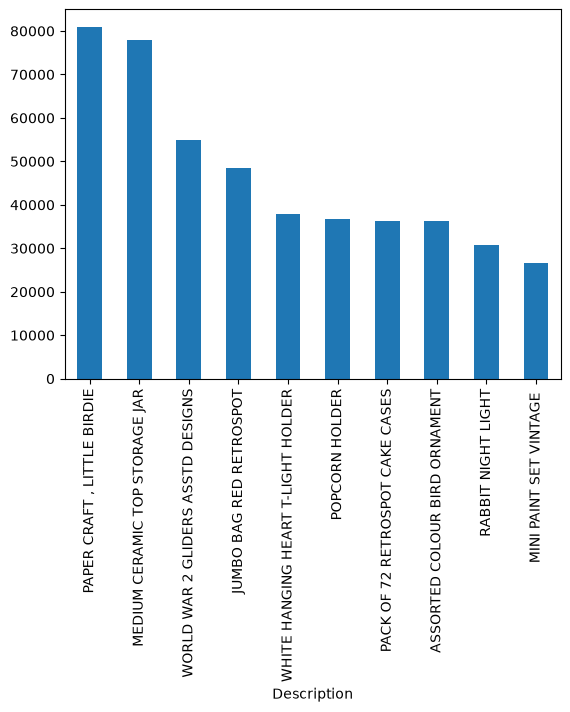

In [57]:
import matplotlib.pyplot as plt

top_products.plot(kind='bar')
plt.show()

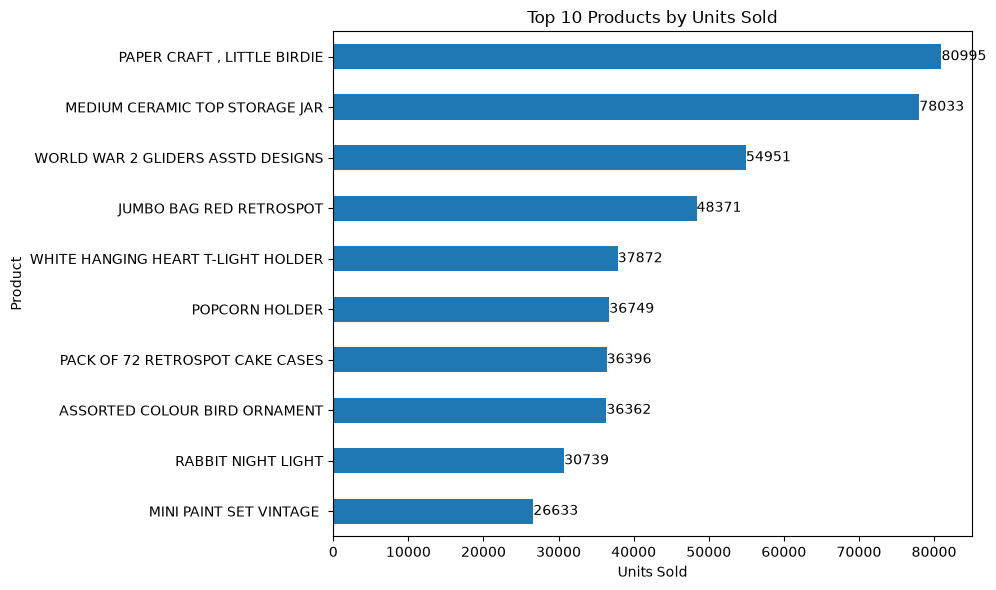

In [75]:
ax=top_products.sort_values().plot(kind='barh', figsize=(10, 6))
ax.bar_label(ax.containers[0], fmt='%.0f')

plt.title('Top 10 Products by Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

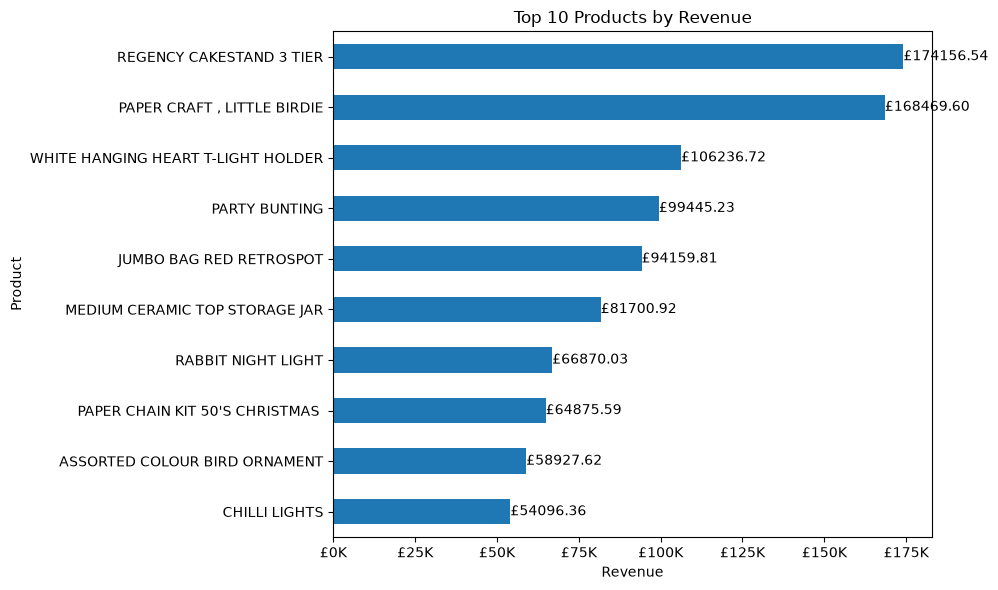

In [83]:
from matplotlib.ticker import FuncFormatter
top_revenue_products = (
    product_sales.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
ax =top_revenue_products.sort_values().plot(kind='barh',figsize=(10, 6))
ax.bar_label(ax.containers[0], fmt='£%.2f')
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'£{x/1000:.0f}K')
)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [62]:
top_countries_orders = (
    country_orders
    .sort_values(ascending=False)
    .head(10)
)

top_countries_orders

Country
United Kingdom    18019
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

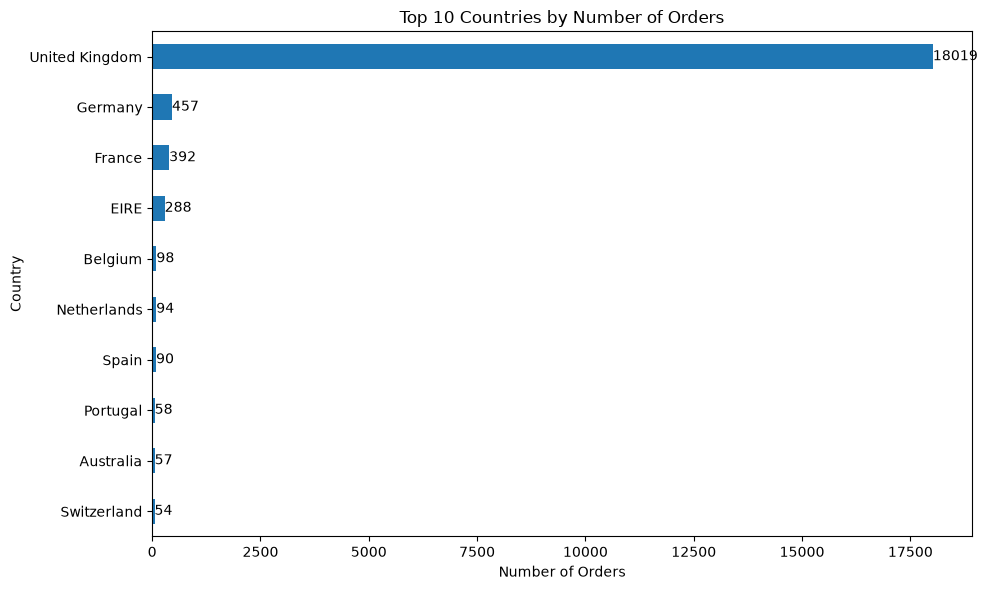

In [77]:
ax=top_countries_orders.sort_values().plot(kind='barh', figsize=(10, 6))
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.title('Top 10 Countries by Number of Orders')   
plt.xlabel('Number of Orders')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

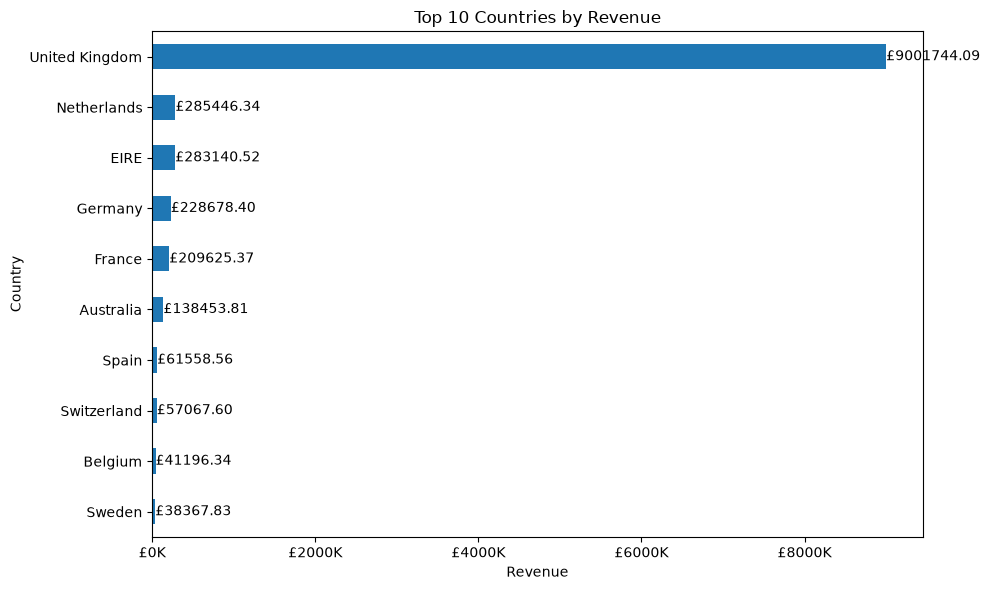

In [85]:
top_countries_revenue = (
    country_revenue
    .sort_values(ascending=False)
    .head(10)
)
ax = top_countries_revenue.sort_values().plot(kind='barh', figsize=(10, 6))
ax.bar_label(ax.containers[0], fmt='£%.2f')
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'£{x/1000:.0f}K')
)
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [66]:
hourly_orders = (
    sales_df.groupby('Hour')['InvoiceNo']
    .nunique()
    .sort_index()
)
hourly_orders

Hour
6        1
7       29
8      566
9     1484
10    2361
11    2396
12    3220
13    2753
14    2457
15    2336
16    1335
17     667
18     192
19     146
20      18
Name: InvoiceNo, dtype: int64

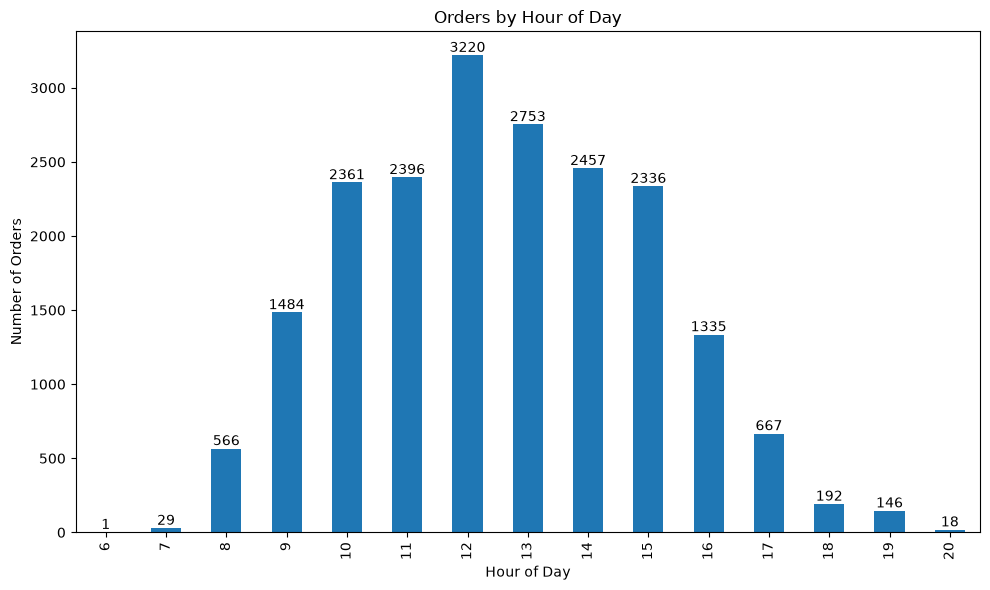

In [79]:
ax = hourly_orders.plot(
    kind='bar',
    figsize=(10, 6)
)
ax.bar_label(ax.containers[0], fmt='%.0f')

plt.title('Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [69]:
weekday_orders = (
    sales_df.groupby('Day')['InvoiceNo']
    .nunique()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
)
weekday_orders

Day
Monday       3126.0
Tuesday      3554.0
Wednesday    3690.0
Thursday     4246.0
Friday       3140.0
Saturday        NaN
Sunday       2204.0
Name: InvoiceNo, dtype: float64

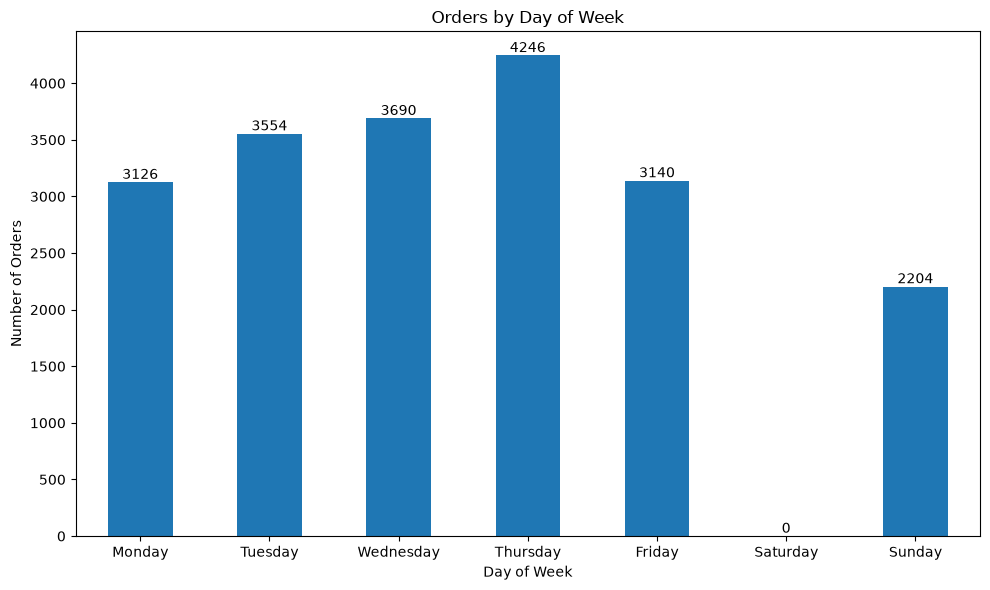

In [86]:
weekday_orders.plot(
    kind='bar',
    figsize=(10, 6)
)
weekday_orders = weekday_orders.fillna(0)
ax = weekday_orders.plot(
    kind='bar',
    figsize=(10, 6)
)

ax.bar_label(ax.containers[0], fmt='%.0f')

plt.title('Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [72]:
customer_type = pd.Series(
    {
        'One-time': one_time_customers,
        'Repeat': repeat_customers
    }
)

customer_type

One-time    1493
Repeat      2845
dtype: int64

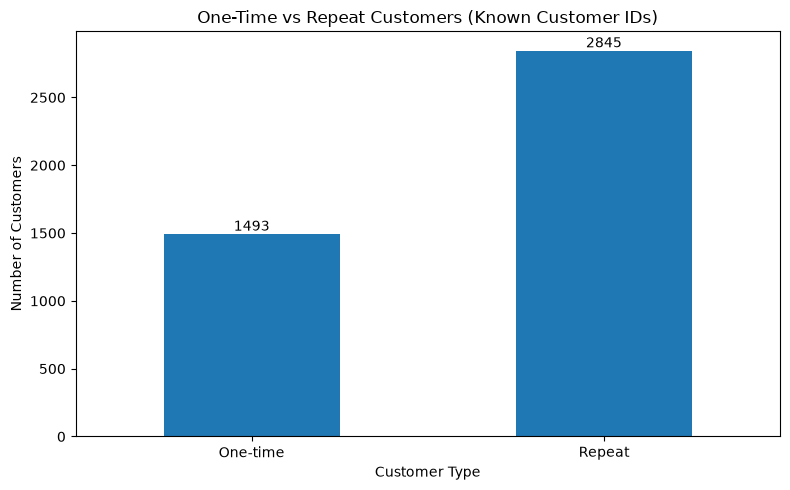

In [87]:
ax=customer_type.plot(
    kind='bar',
    figsize=(8, 5)
)
    
ax.bar_label(ax.containers[0], fmt='%.0f')

plt.title('One-Time vs Repeat Customers (Known Customer IDs)')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [89]:
product_order_frequency = (
    sales_df.groupby('Description')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
product_order_frequency

Description
WHITE HANGING HEART T-LIGHT HOLDER    2256
JUMBO BAG RED RETROSPOT               2089
REGENCY CAKESTAND 3 TIER              1988
PARTY BUNTING                         1685
LUNCH BAG RED RETROSPOT               1564
ASSORTED COLOUR BIRD ORNAMENT         1455
SET OF 3 CAKE TINS PANTRY DESIGN      1385
PACK OF 72 RETROSPOT CAKE CASES       1320
LUNCH BAG  BLACK SKULL.               1273
NATURAL SLATE HEART CHALKBOARD        1249
Name: InvoiceNo, dtype: int64

## Key Business Findings
1. Product performance varies by metric
Product performance differs depending on whether it is measured by unit volume, order frequency, or revenue.
- PAPER CRAFT, LITTLE BIRDIE had the highest unit sales at 80,995 units.
- WHITE HANGING HEART T-LIGHT HOLDER appeared in the highest number of unique orders, with 2,256 orders.
- REGENCY CAKESTAND 3 TIER generated the highest merchandise revenue at £174,156.54.
Business implication: Product performance should be evaluated using multiple metrics rather than relying on unit sales alone.

2. The United Kingdom is the dominant market
The United Kingdom recorded 18,019 unique orders and approximately £9.00 million in sales-associated revenue, far exceeding the other countries.
Business implication: The UK represents the strongest market in this dataset and may warrant continued focus in terms of customer activity and revenue generation.

3. Order volume and revenue can tell different stories
The Netherlands recorded only 94 unique orders but generated approximately £285,446 in revenue, ranking second in total revenue.
Business implication: Order count alone does not indicate the monetary value of a market; average order value should also be considered.

4. Ordering activity is concentrated around midday
The highest number of unique orders occurred at 12 PM, with 3,220 orders. The strongest day-hour combination observed was Wednesday at 12 PM, with 629 orders.
Business implication: The business could consider aligning operational support or promotional activity with peak ordering periods.

5. Repeat purchasing is substantial among identifiable customers
Among customers with a recorded CustomerID, 65.58% placed more than one order.
There were 2,845 repeat customers compared with 1,493 one-time customers.
Business implication: Repeat purchasing appears to be an important part of customer activity in the analyzed dataset.

6. Customer ordering frequency varies substantially
A small group of customers ordered very frequently. For example, Customer 12748 placed 209 unique orders during the observed period.
Business implication: Customer engagement is uneven, with a smaller group of highly active customers contributing a large number of orders.